# GRB Cosmic Merger Rate Density

Converts BNS and BHNS formation efficiencies into **intrinsic merger rate density R(z) [Gpc⁻³ yr⁻¹]** vs redshift, properly accounting for delay times between stellar birth and compact object merger.

Uses the Neijssel et al. (2019) MSSFR model (Madau & Dickinson 2014 SFR + log-normal metallicity evolution) from the COMPAS `FastCosmicIntegration` post-processing library.

**Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first** to verify the underlying classifications.

## 1. Imports

In [183]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

## 2. Cosmological Grid & MSSFR Model

Neijssel et al. (2019) parameters: `mu0=0.035`, `muz=-0.23`, `sigma0=0.39`.  
`redshift_step=0.01` gives 1001 points - sufficient resolution for rate vs redshift plots.

In [184]:
redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)

sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)
print(f"Redshift grid:  {len(redshifts)} points  (0 → {redshifts.max():.0f})")
print(f"time_first_SF:  {time_first_SF:.1f} Myr")
print(f"times range:    {times.min():.1f} – {times.max():.1f} Myr")
print(f"dPdlogZ shape:  {dPdlogZ.shape}")

Redshift grid:  1001 points  (0 → 10)
time_first_SF:  471.4 Myr
times range:    471.4 – 13786.9 Myr
dPdlogZ shape:  (1001, 1201)


## 3. Memory-Efficient Merger Rate Function

`find_formation_and_merger_rates` in COMPAS allocates an `(n_binaries × n_redshifts)` array which  
crashes the kernel for large populations. This replacement accumulates the sum directly, using only  
O(n_redshifts) memory regardless of population size.

**Bug note:** `t_min` must use `times.min()` (age at z_max ≈ 471 Myr), NOT `times[0]` (age at  
z=0 ≈ 13,787 Myr). The `times` array is monotonically *decreasing* (higher z → earlier universe).

In [185]:
def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Memory-efficient intrinsic merger rate density [Gpc⁻³ yr⁻¹] vs redshift.

    For each binary: formation_rate(z) = SFR(z) × dP/dlogZ(z,Z_i) / p_draw × weight_i / meanMassEvolved
    The merger rate at z_merge is the formation rate at the redshift when the binary was born
    (z_form = redshift at age = t(z_merge) - delay_time).
    """
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)   # handles decreasing times correctly

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)

    # times is DECREASING (times[0]=age_z0≈13787 Myr, times[-1]=age_zmax≈471 Myr)
    # t_min must be the *smallest* time in the grid (times.min()), not times[0]
    t_min = max(time_first_SF, times.min())

    total_merger = np.zeros(n_z)

    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]

        t_form = times - COMPAS_delay_times[i]

        # Only process merger redshifts where formation time is within the grid
        valid = (t_form >= t_min)
        if not valid.any():
            continue

        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]

    return total_merger

## 4. BNS: Load Data & Classify

Gottlieb et al. (2023) hybrid classification: `M_crit = 2.8 M☉`, `q_threshold = 1.2`.

In [186]:
path_BNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'
with h5.File(path_BNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1           = fDCO['M1'][...].squeeze()
    mass2           = fDCO['M2'][...].squeeze()
    weights_BNS     = fDCO['weight'][...].squeeze()
    metallicity_BNS = fDCO['Metallicity1'][...].squeeze()
    mergesHubble    = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BNS          = fDCO['tc'][...].squeeze()
    tform_BNS       = fDCO['tform'][...].squeeze()

mask_BNS = (mergesHubble == 1)
M_tot = mass1[mask_BNS] + mass2[mask_BNS]
q     = np.maximum(mass1[mask_BNS], mass2[mask_BNS]) / np.minimum(mass1[mask_BNS], mass2[mask_BNS])

# Gottlieb Figure 2 BNS sub-types
short_BNS_I  = (M_tot < 2.8)                          # Type I:  HMNS remnant powers jet
short_BNS_II = (M_tot >= 2.8) & (q < 1.2)             # Type II: BH + light disk
short_BNS    = short_BNS_I | short_BNS_II              # combined (kept for backward compat)
long_BNS     = (M_tot >= 2.8) & (q >= 1.2)            # Long cbGRB: BH + massive disk

delay_BNS = (tform_BNS + tc_BNS)[mask_BNS]
Z_BNS     = metallicity_BNS[mask_BNS]
w_BNS     = weights_BNS[mask_BNS]

print(f"Merging BNS:       {mask_BNS.sum():,}")
print(f"Short Type I  (HMNS):      {short_BNS_I.sum():,}  ({100*short_BNS_I.mean():.1f}%)")
print(f"Short Type II (BH+disk):   {short_BNS_II.sum():,}  ({100*short_BNS_II.mean():.1f}%)")
print(f"Long  cbGRB  (BH+big disk):{long_BNS.sum():,}  ({100*long_BNS.mean():.1f}%)")


Merging BNS:       233,137
Short Type I  (HMNS):      160,646  (68.9%)
Short Type II (BH+disk):   29,209  (12.5%)
Long  cbGRB  (BH+big disk):43,282  (18.6%)


## 5. BNS Merger Rate Density

`meanMassEvolved = 77,708,655 M☉` - total stellar mass per metallicity simulation (from `GRB_BNS.ipynb`).  
This normalizes the per-binary weights into physical units of Gpc⁻³ yr⁻¹.

In [187]:
meanMassEvolved_BNS = 77708655   # M_sun
n_formed_BNS        = sfr / meanMassEvolved_BNS

merger_rates_BNS = {}
classes_BNS = [
    ('Short cbGRB (Type I)',  short_BNS_I),
    ('Short cbGRB (Type II)', short_BNS_II),
    ('Short cbGRB',           short_BNS),
    ('Long cbGRB',            long_BNS),
    ('All BNS',               np.ones(len(delay_BNS), dtype=bool)),
]
for label, mask_grb in classes_BNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_BNS[mask_grb],
    )
    merger_rates_BNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (Type I) (160,646 systems)...
  z=0: 1085.6  |  z=1: 6,528.6  Gpc^-3 yr^-1
Computing Short cbGRB (Type II) (29,209 systems)...
  z=0: 46.0  |  z=1: 291.1  Gpc^-3 yr^-1
Computing Short cbGRB (189,855 systems)...
  z=0: 1131.6  |  z=1: 6,819.6  Gpc^-3 yr^-1
Computing Long cbGRB (43,282 systems)...
  z=0: 74.5  |  z=1: 788.2  Gpc^-3 yr^-1
Computing All BNS (233,137 systems)...
  z=0: 1206.1  |  z=1: 7,607.8  Gpc^-3 yr^-1


## 6. BHNS: Load Data & Classify (Foucart, a=0.5)

BH spin `a = 0.5` as fiducial. The Foucart (2012) disk mass formula with physical  
disruption pre-check determines whether each BHNS merger produces a GRB.

In [188]:
def r_isco(a_BH):
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    return 3 + Z2 - np.sign(a_BH + 1e-10) * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0):
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    q_r      = M_NS / M_BH
    f_roche  = 0.49 * q_r**(2/3) / (0.6 * q_r**(2/3) + np.log(1 + q_r**(1/3)))
    r_tidal  = (R_NS_km * 1e3) / f_roche
    r_ISCO   = r_isco(a_BH) * G * M_BH * Msun / c**2
    disrupted = r_tidal > r_ISCO
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    r_hat = r_isco(a_BH) * M_BH / (M_BH + M_NS)
    M_disk = np.maximum(0.0, 0.406*(1-2*C_NS)/eta**(1/3) - 0.139*r_hat*C_NS + 0.255) * M_NS
    return np.where(disrupted, M_disk, 0.0)

path_BHNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
with h5.File(path_BHNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    M_BH_all     = fDCO['M1'][...].squeeze()
    M_NS_all     = fDCO['M2'][...].squeeze()
    weights_BHNS = fDCO['weight'][...].squeeze()
    Z_BHNS_all   = fDCO['Metallicity1'][...].squeeze()
    merges_BHNS  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BHNS      = fDCO['tc'][...].squeeze()
    tform_BHNS   = fDCO['tform'][...].squeeze()
    stype1       = fDCO['stellarType1'][...].squeeze()

# correct BH/NS assignment
is_BH1   = (stype1 == 14)
M1_orig  = M_BH_all.copy(); M2_orig = M_NS_all.copy()
M_BH_all = np.where(is_BH1, M1_orig, M2_orig)
M_NS_all = np.where(is_BH1, M2_orig, M1_orig)

mask_BHNS = (merges_BHNS == 1)
BH = M_BH_all[mask_BHNS]; NS = M_NS_all[mask_BHNS]
M_disk     = foucart_disk_mass(BH, NS, a_BH=0.5)

# Gottlieb Figure 2 BHNS classes (fiducial spin a=0.5)
no_BHNS    = (M_disk == 0.0)                     # No disruption -> no GRB
short_BHNS = (M_disk > 0.0) & (M_disk < 0.1)    # Small disk -> short cbGRB
long_BHNS  = (M_disk >= 0.1)                     # Massive disk -> long cbGRB

delay_BHNS = (tform_BHNS + tc_BHNS)[mask_BHNS]
Z_BHNS     = Z_BHNS_all[mask_BHNS]
w_BHNS     = weights_BHNS[mask_BHNS]

print(f"Merging BHNS: {mask_BHNS.sum():,}")
print(f"No GRB:       {no_BHNS.sum():,}  ({100*no_BHNS.mean():.1f}%)")
print(f"Short cbGRB:  {short_BHNS.sum():,}  ({100*short_BHNS.mean():.1f}%)")
print(f"Long  cbGRB:  {long_BHNS.sum():,}  ({100*long_BHNS.mean():.1f}%)")


Merging BHNS: 1,525,553
No GRB:       1,413,206  (92.6%)
Short cbGRB:  0  (0.0%)
Long  cbGRB:  112,347  (7.4%)


## 7. BHNS Merger Rate Density

In [189]:
meanMassEvolved_BHNS = 77708655   # M_sun (same simulation setup)
n_formed_BHNS        = sfr / meanMassEvolved_BHNS

merger_rates_BHNS = {}
classes_BHNS = [
    ('Short cbGRB (a=0.5)', short_BHNS),
    ('Long cbGRB (a=0.5)',  long_BHNS),
    ('All BHNS',            np.ones(len(delay_BHNS), dtype=bool)),
]
for label, mask_grb in classes_BHNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[mask_grb], delay_BHNS[mask_grb], w_BHNS[mask_grb],
    )
    merger_rates_BHNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (a=0.5) (0 systems)...
  z=0: 0.0  |  z=1: 0.0  Gpc^-3 yr^-1
Computing Long cbGRB (a=0.5) (112,347 systems)...
  z=0: 632.2  |  z=1: 3,319.6  Gpc^-3 yr^-1
Computing All BHNS (1,525,553 systems)...
  z=0: 2246.6  |  z=1: 12,204.3  Gpc^-3 yr^-1


## 7b. BHNS Spin Sensitivity on Long cbGRB Rate

BH spin is the dominant uncertainty for BHNS classification. The same BHNS population  
is re-classified with the Foucart (2012) formula for `a = 0.0, 0.5, 0.7` and the  
full cosmic rate is recomputed for each case.  
This directly answers: *how much does the long cbGRB rate prediction depend on the unknown BH spin?*

a=0.0: Long cbGRB = 16,428  (1.1%)
  z=0: 199.4  |  z=1: 1,166.4  Gpc⁻³ yr⁻¹
a=0.5: Long cbGRB = 112,347  (7.4%)
  z=0: 632.2  |  z=1: 3,319.6  Gpc⁻³ yr⁻¹
a=0.7: Long cbGRB = 342,240  (22.4%)
  z=0: 1138.5  |  z=1: 5,798.1  Gpc⁻³ yr⁻¹


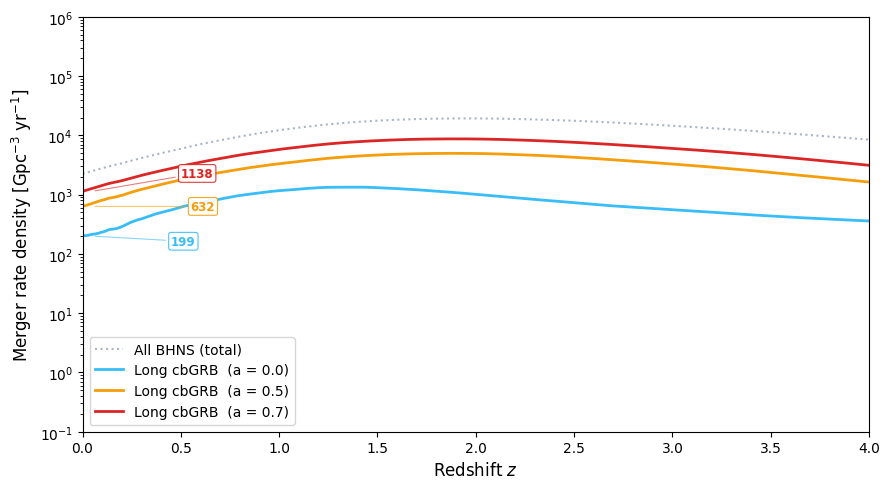

In [190]:
spin_colors = {0.0: '#38BDF8', 0.5: '#F59E0B', 0.7: '#DC2626'}
merger_rates_BHNS_spin = {}

for a in [0.0, 0.5, 0.7]:
    M_disk_a = foucart_disk_mass(BH, NS, a_BH=a)
    long_a   = (M_disk_a >= 0.1)
    print(f'a={a}: Long cbGRB = {long_a.sum():,}  ({100*long_a.mean():.1f}%)')
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[long_a], delay_BHNS[long_a], w_BHNS[long_a],
    )
    merger_rates_BHNS_spin[a] = rate
    print(f'  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9')

# Per-spin annotation offsets to stagger labels and avoid overlap
annot_offsets = {0.0: (0.45, 0.82), 0.5: (0.55, 1.0), 0.7: (0.50, 2.0)}

fig, ax = plt.subplots(figsize=(9, 5))

# Gray dotted reference: total BHNS merger rate
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
        color='#94A3B8', lw=1.5, ls=':', alpha=0.8, label='All BHNS (total)')

# Spin curves with staggered z=0 annotations
for a, color in spin_colors.items():
    rate = merger_rates_BHNS_spin[a]
    ax.plot(redshifts, rate, color=color, lw=2, label=f'Long cbGRB  (a = {a})')
    z0_val = rate[0]
    if z0_val > 0:
        xt, ym = annot_offsets[a]
        ax.annotate(f'{z0_val:.0f}',
                    xy=(0.05, z0_val), xytext=(xt, z0_val * ym),
                    color=color, fontsize=8.5, fontweight='bold', va='center',
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.6),
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              edgecolor=color, alpha=0.9, lw=0.8))

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e6)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bhns_spin_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5b. BNS M_crit Sensitivity (EOS Uncertainty)

The critical total mass `M_crit = 2.8 M☉` separating HMNS-powered short cbGRBs from  
BH-disk systems is uncertain by ±0.2 M☉ depending on the neutron star equation of state.  
Vary from 2.6–3.0 M☉ to show the resulting uncertainty band on the short and long cbGRB rates.  
The solid black line is the fiducial value used throughout the analysis.

M_crit=2.6: Short=189,138 (81.1%)  Long=43,999 (18.9%)
M_crit=2.8: Short=189,855 (81.4%)  Long=43,282 (18.6%)
M_crit=3.0: Short=203,424 (87.3%)  Long=29,713 (12.7%)


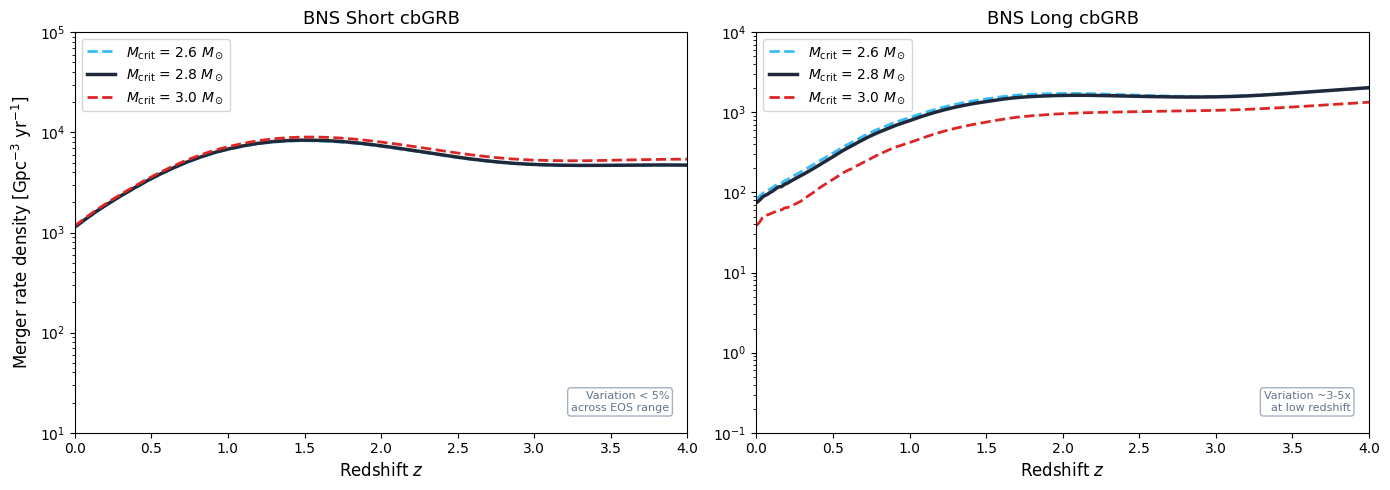

In [203]:
mcrit_colors = {2.6: '#38BDF8', 2.8: '#1E293B', 3.0: '#DC2626'}
mcrit_styles = {2.6: '--',         2.8: '-',      3.0: '--'}
rates_mcrit_short = {}
rates_mcrit_long  = {}

for Mc in [2.6, 2.8, 3.0]:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    print(f'M_crit={Mc}: Short={s.sum():,} ({100*s.mean():.1f}%)  Long={l.sum():,} ({100*l.mean():.1f}%)')
    rates_mcrit_short[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[s], delay_BNS[s], w_BNS[s],
    )
    rates_mcrit_long[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[l], delay_BNS[l], w_BNS[l],
    )

# Independent y-axes so each panel uses its own data range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for Mc in [2.6, 2.8, 3.0]:
    c, ls = mcrit_colors[Mc], mcrit_styles[Mc]
    lw = 2.5 if Mc == 2.8 else 2
    axes[0].plot(redshifts, rates_mcrit_short[Mc], color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')
    axes[1].plot(redshifts, rates_mcrit_long[Mc],  color=c, ls=ls, lw=lw,
                 label=f'$M_{{\mathrm{{crit}}}}$ = {Mc} $M_\odot$')

for ax, title, ylims in zip(axes,
                             ['Short cbGRB', 'Long cbGRB'],
                             [(1e1, 1e5),    (1e-1, 1e4)]):
    ax.set_xlim(0, 4)
    ax.set_ylim(*ylims)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {title}', fontsize=13)
    ax.legend(fontsize=10, loc='upper left')
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)

# Robustness annotations -- bottom right of each panel
axes[0].text(0.97, 0.05, 'Variation < 5%\nacross EOS range',
             transform=axes[0].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))
axes[1].text(0.97, 0.05, 'Variation ~3-5x\nat low redshift',
             transform=axes[1].transAxes, fontsize=8, color='#64748B',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#94A3B8', alpha=0.85))

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_mcrit_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 5c. Model K vs Model A: Binary Physics Uncertainty

Model K uses a lower common envelope efficiency (α_CE = 0.5) vs the fiducial Model A (α_CE = 1.0).  
Comparing the full cosmic rates between models shows how sensitive the predicted GRB rates are  
to uncertain binary evolution physics - independent of the EOS or BH spin assumptions.

Both short and long cbGRB rates are compared, with the shaded band showing the model uncertainty range.

Model K - Merging BNS: 234,963
Short cbGRB: 191,290  (81.4%)
Long  cbGRB: 43,673  (18.6%)
Computing Model K Short cbGRB (191,290 systems)...
  z=0: 1304.8  Gpc-3 yr-1
Computing Model K Long cbGRB (43,673 systems)...
  z=0: 200.6  Gpc-3 yr-1
Computing Model K All BNS (234,963 systems)...
  z=0: 1505.4  Gpc-3 yr-1


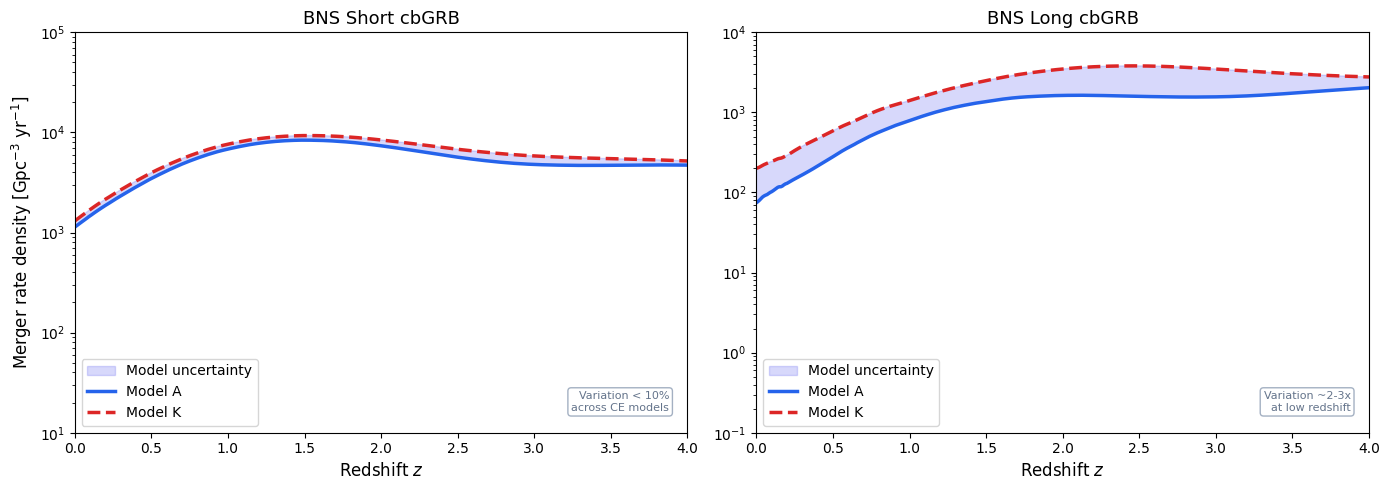

In [192]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'
with h5.File(path_K, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1_K   = fDCO['M1'][...].squeeze()
    mass2_K   = fDCO['M2'][...].squeeze()
    weights_K = fDCO['weight'][...].squeeze()
    Z_K_all   = fDCO['Metallicity1'][...].squeeze()
    merges_K  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_K      = fDCO['tc'][...].squeeze()
    tform_K   = fDCO['tform'][...].squeeze()

mask_K  = (merges_K == 1)
M_tot_K = mass1_K[mask_K] + mass2_K[mask_K]
q_K     = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K = (M_tot_K < 2.8) | ((M_tot_K >= 2.8) & (q_K < 1.2))
long_K  = (M_tot_K >= 2.8) & (q_K >= 1.2)

delay_K = (tform_K + tc_K)[mask_K]
Z_K     = Z_K_all[mask_K]
w_K     = weights_K[mask_K]

print(f'Model K - Merging BNS: {mask_K.sum():,}')
print(f'Short cbGRB: {short_K.sum():,}  ({100*short_K.mean():.1f}%)')
print(f'Long  cbGRB: {long_K.sum():,}  ({100*long_K.mean():.1f}%)')

merger_rates_K = {}
for label, mask_grb in [('Short cbGRB', short_K),
                          ('Long cbGRB',  long_K),
                          ('All BNS',     np.ones(len(delay_K), dtype=bool))]:
    print(f'Computing Model K {label} ({mask_grb.sum():,} systems)...')
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_K[mask_grb], delay_K[mask_grb], w_K[mask_grb],
    )
    merger_rates_K[label] = rate
    print(f'  z=0: {rate[0]:.1f}  Gpc-3 yr-1')

# ---- Plot Model A vs Model K ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip([ax1, ax2], ['Short cbGRB', 'Long cbGRB']):
    rA = merger_rates_BNS[label]
    rK = merger_rates_K[label]
    # Uncertainty band beneath lines
    ax.fill_between(redshifts,
                    np.minimum(rA, rK), np.maximum(rA, rK),
                    alpha=0.25, color='#6366F1', label='Model uncertainty')
    ax.plot(redshifts, rA, color='#2563EB', lw=2.5, label='Model A')
    ax.plot(redshifts, rK, color='#DC2626',  lw=2.5, ls='--', label='Model K')
    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {label}', fontsize=13)
    ax.legend(fontsize=10, loc='lower left')
    pass  # annotations set per-panel below

# Per-panel annotations (short: robust; long: sensitive to CE efficiency)
ax1.text(0.97, 0.05, 'Variation < 10%\nacross CE models',
         transform=ax1.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))
ax2.text(0.97, 0.05, 'Variation ~2-3x\nat low redshift',
         transform=ax2.transAxes, fontsize=8, color='#64748B',
         ha='right', va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                   edgecolor='#94A3B8', alpha=0.85))

# Set ylim AFTER all plotting to prevent autoscale override
ax1.set_ylim(1e1, 1e5)
ax2.set_ylim(1e-1, 1e4)

ax1.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_model_ak.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. Combined BNS + BHNS Plot

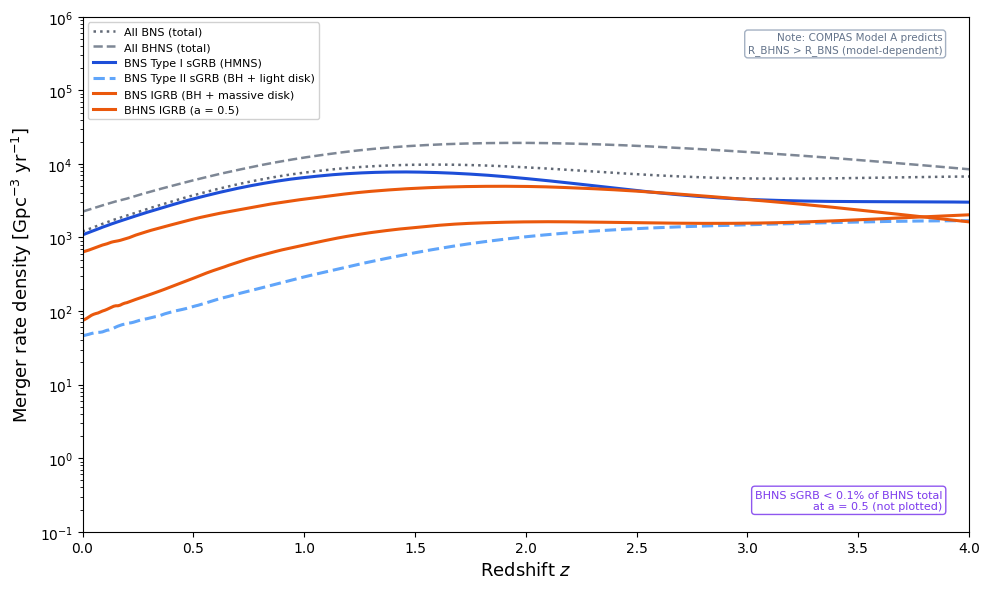

In [193]:
fig, ax = plt.subplots(figsize=(10, 6))

# ---- Totals (black, background reference) ----
ax.plot(redshifts, merger_rates_BNS['All BNS'],
        color='#1E293B', lw=1.8, ls=':', alpha=0.7, label='All BNS (total)')
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
        color='#475569', lw=1.8, ls='--', alpha=0.7, label='All BHNS (total)')

# ---- BNS channels ----
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],
        color='#1D4ED8', lw=2.2, ls='-',
        label=r'BNS Type I sGRB (HMNS)')
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'],
        color='#60A5FA', lw=2.2, ls='--',
        label=r'BNS Type II sGRB (BH + light disk)')
ax.plot(redshifts, merger_rates_BNS['Long cbGRB'],
        color='#EA580C', lw=2.2, ls='-',
        label=r'BNS lGRB (BH + massive disk)')

# ---- BHNS channels (a=0.5) ----
ax.plot(redshifts, merger_rates_BHNS['Long cbGRB (a=0.5)'],
        color='#EA580C', lw=2.2, ls='-',
        label=r'BHNS lGRB (a = 0.5)')

# Legend -- upper left, reduced font to avoid clipping
ax.legend(fontsize=8, loc='upper left', framealpha=0.9)

# Standalone annotation for suppressed BHNS sGRB channel
ax.text(0.97, 0.04,
        'BHNS sGRB < 0.1% of BHNS total\nat a = 0.5 (not plotted)',
        transform=ax.transAxes, fontsize=8, color='#7C3AED',
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#7C3AED', alpha=0.85))

# Flag if BHNS total exceeds BNS total at z=0 -- model-dependent result
if merger_rates_BHNS['All BHNS'][0] > merger_rates_BNS['All BNS'][0]:
    ax.text(0.97, 0.97,
            'Note: COMPAS Model A predicts\nR_BHNS > R_BNS (model-dependent)',
            transform=ax.transAxes, fontsize=7.5, color='#64748B',
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#94A3B8', alpha=0.85))

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e6)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_combined_bns_bhns.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 9. Unified Figure 2 Rate Plot: All cbGRB Classes

Full Gottlieb et al. (2023) Figure 2 classification across cosmic time.
All five physically distinct outcomes are shown on a single axis:
- **BNS Type I sGRB** (HMNS-powered): M_tot < M_crit
- **BNS Type II sGRB** (BH + light disk): M_tot >= M_crit, q < 1.2
- **BNS lGRB** (BH + massive disk): M_tot >= M_crit, q >= 1.2
- **BHNS sGRB** (small disk, Foucart a=0.5): 0 < M_disk < 0.1 M_sun
- **BHNS lGRB** (massive disk, Foucart a=0.5): M_disk >= 0.1 M_sun

BHNS sGRB  z=0: 0.000  Gpc-3 yr-1
BHNS lGRB  z=0: 632.240  Gpc-3 yr-1
BHNS total z=0: 2246.644  Gpc-3 yr-1
BHNS sGRB fraction of total at z=0: 0.0000


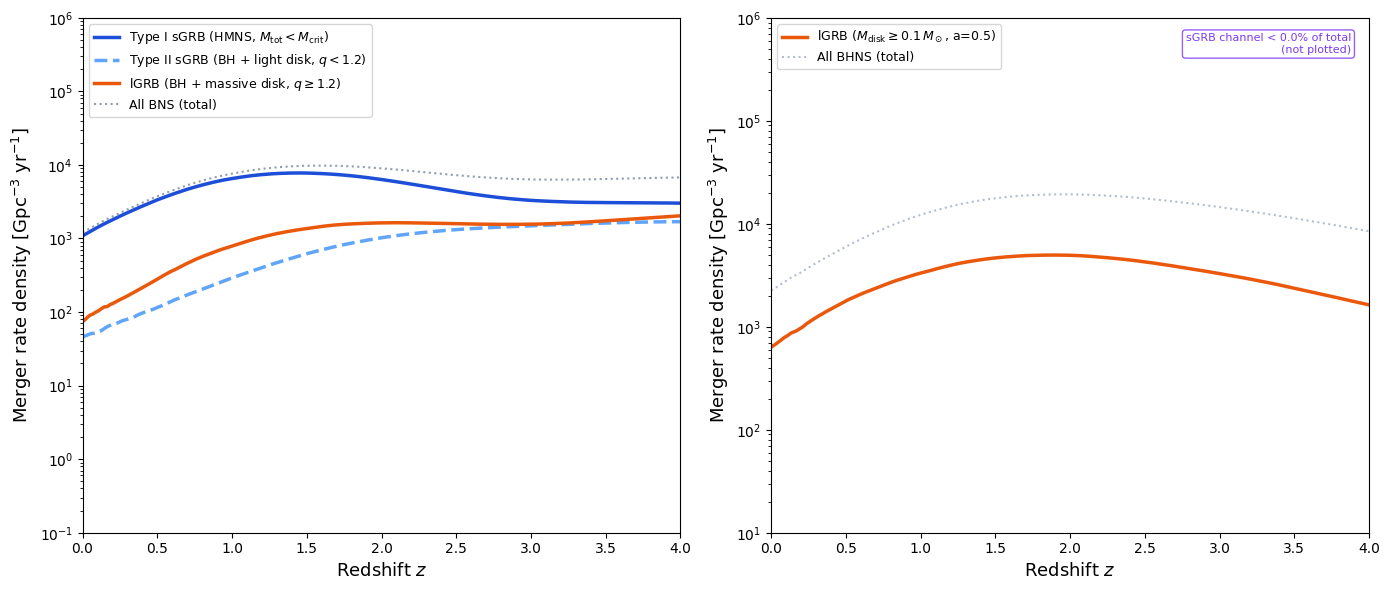

In [205]:
# Diagnostic: check BHNS sGRB vs total at z=0 to see if the channel is negligible
bhns_sgrb_arr  = merger_rates_BHNS['Short cbGRB (a=0.5)']
bhns_lgrb_arr  = merger_rates_BHNS['Long cbGRB (a=0.5)']
bhns_total_arr = merger_rates_BHNS['All BHNS']
print(f"BHNS sGRB  z=0: {bhns_sgrb_arr[0]:.3f}  Gpc-3 yr-1")
print(f"BHNS lGRB  z=0: {bhns_lgrb_arr[0]:.3f}  Gpc-3 yr-1")
print(f"BHNS total z=0: {bhns_total_arr[0]:.3f}  Gpc-3 yr-1")
sgrb_frac = bhns_sgrb_arr[0] / bhns_total_arr[0] if bhns_total_arr[0] > 0 else 0.0
print(f"BHNS sGRB fraction of total at z=0: {sgrb_frac:.4f}")

fig, (ax_bns, ax_bhns) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left panel: BNS channels ----
ax_bns.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],
            color='#1D4ED8', lw=2.5, ls='-',
            label=r'Type I sGRB (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$)')
ax_bns.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'],
            color='#60A5FA', lw=2.5, ls='--',
            label=r'Type II sGRB (BH + light disk, $q < 1.2$)')
ax_bns.plot(redshifts, merger_rates_BNS['Long cbGRB'],
            color='#EA580C', lw=2.5, ls='-',
            label=r'lGRB (BH + massive disk, $q \geq 1.2$)')
ax_bns.plot(redshifts, merger_rates_BNS['All BNS'],
            color='#64748B', lw=1.5, ls=':', alpha=0.7, label='All BNS (total)')
ax_bns.set_xlim(0, 4)
ax_bns.set_ylim(1e-1, 1e6)
ax_bns.set_yscale('log')
ax_bns.set_xlabel('Redshift $z$', fontsize=13)
ax_bns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bns.legend(fontsize=9, loc='upper left')

# ---- Right panel: BHNS channels (a=0.5 fiducial) ----
# Only show the sGRB line if it is non-negligible (>5% of total); otherwise note in panel
if sgrb_frac > 0.05:
    ax_bhns.plot(redshifts, bhns_sgrb_arr,
                 color='#7C3AED', lw=2.5, ls='--',
                 label=r'sGRB ($M_\mathrm{disk} < 0.1\,M_\odot$, a=0.5)')
ax_bhns.plot(redshifts, bhns_lgrb_arr,
             color='#EA580C', lw=2.5, ls='-',
             label=r'lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$, a=0.5)')
ax_bhns.plot(redshifts, bhns_total_arr,
             color='#94A3B8', lw=1.5, ls=':', alpha=0.7, label='All BHNS (total)')

# Annotate if sGRB channel is negligible
if sgrb_frac <= 0.05:
    ax_bhns.text(0.97, 0.97,
                 f'sGRB channel < {sgrb_frac*100:.1f}% of total\n(not plotted)',
                 transform=ax_bhns.transAxes, fontsize=8, color='#7C3AED',
                 ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#7C3AED', alpha=0.8))

ax_bhns.set_xlim(0, 4)
ax_bhns.set_ylim(1e1, 1e6)
ax_bhns.set_yscale('log')
ax_bhns.set_xlabel('Redshift $z$', fontsize=13)
ax_bhns.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax_bhns.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_figure2_unified.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 10. Mass Distributions at Redshift Slices

How does the merging BNS mass distribution shift with cosmic time? At high redshift
low-metallicity star formation dominates, which can change the typical NS mass and
shift the long vs short cbGRB balance. Here each binary is weighted by its
contribution to the merger rate at a specific target redshift.

In [195]:
def per_system_rate_weights(z_target, redshifts, times, time_first_SF,
                             n_formed, dPdlogZ, metallicities, p_draw,
                             COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Per-system contribution to the merger rate at z_target.
    Mirrors compute_merger_rate but returns an array of individual weights
    instead of summing them, so histograms can be weighted by rate contribution.
    """
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)

    j_target = np.argmin(np.abs(redshifts - z_target))
    t_merge  = times[j_target]

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min  = max(time_first_SF, times.min())

    out    = np.zeros(len(COMPAS_weights))
    t_form = t_merge - COMPAS_delay_times
    valid  = t_form >= t_min

    if valid.any():
        z_form     = times_to_z(t_form[valid])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int),
                             0, len(redshifts) - 1)
        out[valid] = (n_formed[z_form_idx]
                      * dPdlogZ[z_form_idx, Z_bins[valid]]
                      / p_draw
                      * COMPAS_weights[valid])
    return out


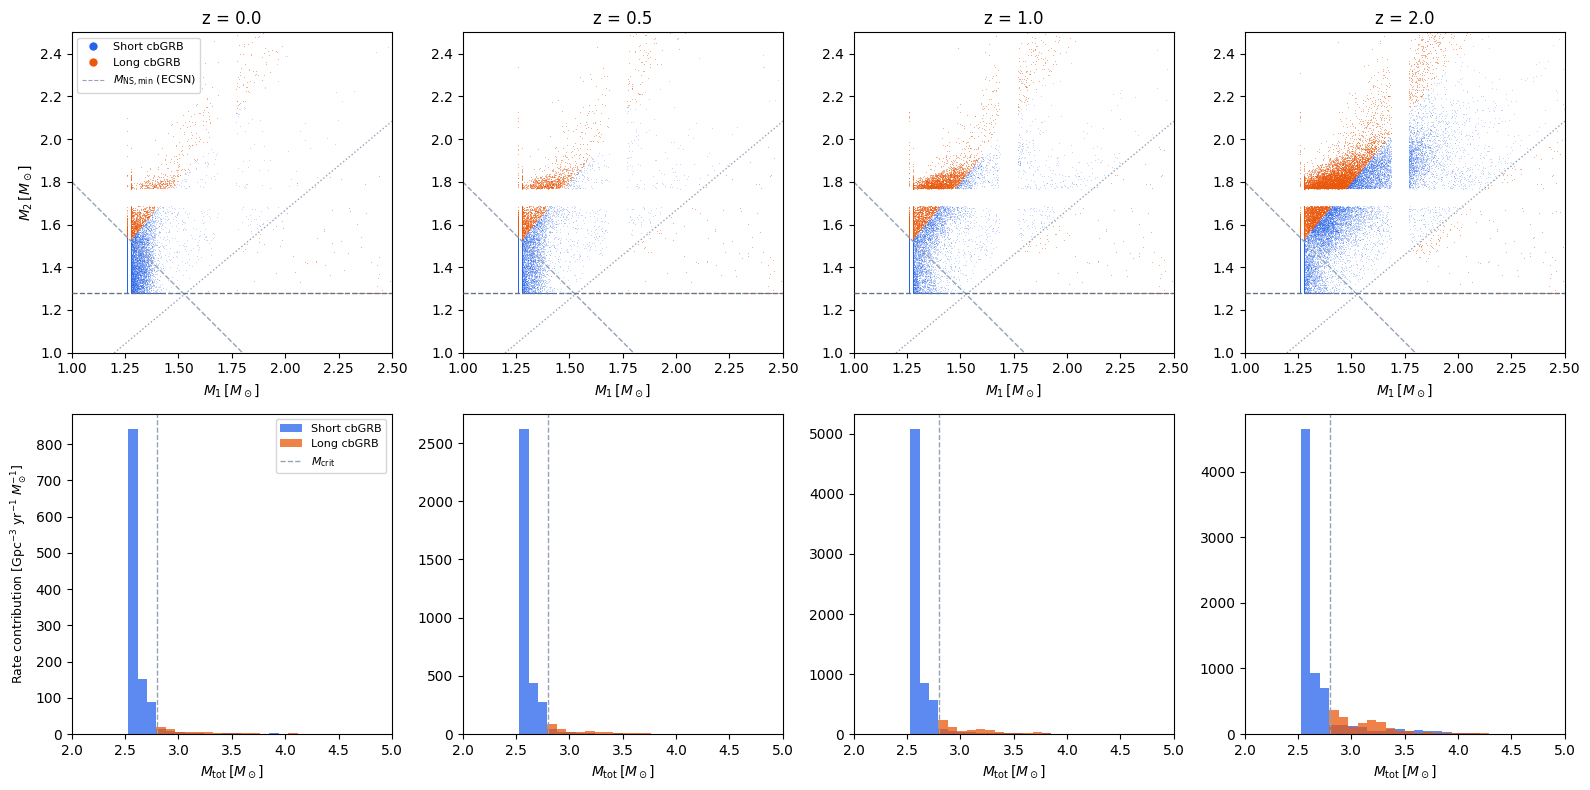

In [196]:
M1_m = mass1[mask_BNS]
M2_m = mass2[mask_BNS]

z_slices  = [0.0, 0.5, 1.0, 2.0]
bins_mtot = np.linspace(2.0, 5.0, 35)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )

    # --- Top row: M1 vs M2 scatter (top 40 % rate contributors only) ---
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    # Blue first (zorder=1), orange on top (zorder=2) — long cbGRB classification visible
    ax.scatter(M1_m[vis & short_BNS], M2_m[vis & short_BNS],
               s=0.3, c='#2563EB', alpha=0.30, linewidths=0, zorder=1)
    ax.scatter(M1_m[vis & long_BNS],  M2_m[vis & long_BNS],
               s=0.3, c='#EA580C', alpha=0.60, linewidths=0, zorder=2)
    # classification lines
    m_vals = np.linspace(1.0, 2.5, 200)
    ax.plot(m_vals, 2.8 - m_vals, color='#94A3B8', lw=1, ls='--')   # M_tot = 2.8
    ax.plot(m_vals, m_vals / 1.2,  color='#94A3B8', lw=1, ls=':')   # q = 1.2
    # ECSN floor: NS remnants from electron-capture SNe pile up at a fixed mass
    ecsn_mass = M2_m.min()
    ax.axhline(ecsn_mass, color='#64748B', lw=1.0, ls='--', zorder=3)
    ax.set_xlim(1.0, 2.5); ax.set_ylim(1.0, 2.5)
    ax.set_title(f'z = {z_s}', fontsize=12)
    ax.set_xlabel(r'$M_1\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_2\,[M_\odot]$', fontsize=10)
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
                   markersize=7, label='Short cbGRB'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
                   markersize=7, label='Long cbGRB'),
            Line2D([0],[0], color='#94A3B8', lw=0.8, ls='--',
                   label=r'$M_\mathrm{NS,min}$ (ECSN)'),
        ], fontsize=8)

    # --- Bottom row: M_tot histogram ---
    ax2 = axes[1, col]
    ax2.hist(M_tot[short_BNS], bins=bins_mtot, weights=w[short_BNS],
             color='#2563EB', alpha=0.75, label='Short cbGRB')
    ax2.hist(M_tot[long_BNS],  bins=bins_mtot, weights=w[long_BNS],
             color='#EA580C', alpha=0.75, label='Long cbGRB')
    ax2.axvline(2.8, color='#94A3B8', ls='--', lw=1,
                label=r'$M_\mathrm{crit}$')
    ax2.set_xlim(2.0, 5.0)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel(r'$M_\mathrm{tot}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'Rate contribution [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]',
                       fontsize=9)
        ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_dist_redshift_slices.png', dpi=150, bbox_inches='tight')
plt.show()


short + long at z=0:   93.8 + 6.2 = 100.0%
short + long at z=5:   63.7 + 36.3 = 100.0%


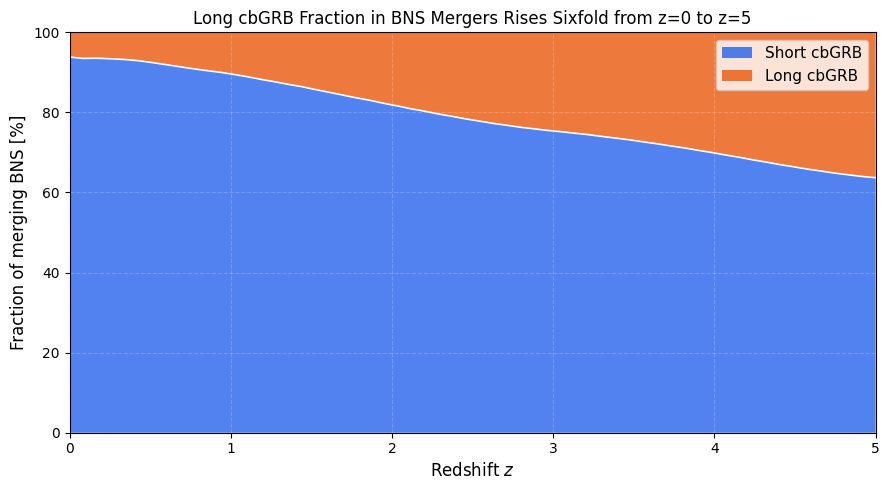

In [197]:
z_arr      = np.linspace(0.0, 5.0, 60)
frac_short_arr = []
frac_long_arr  = []

for z_s in z_arr:
    w     = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )
    r_tot = w.sum()
    if r_tot > 0:
        frac_short_arr.append(100 * w[short_BNS].sum() / r_tot)
        frac_long_arr.append( 100 * w[long_BNS].sum()  / r_tot)
    else:
        frac_short_arr.append(np.nan)
        frac_long_arr.append(np.nan)

frac_short_arr = np.array(frac_short_arr)
frac_long_arr  = np.array(frac_long_arr)

# Sanity check: short + long = 100% at every z (exhaustive by construction)
print(f"short + long at z=0:   {frac_short_arr[0]:.1f} + {frac_long_arr[0]:.1f} = "
      f"{frac_short_arr[0]+frac_long_arr[0]:.1f}%")
print(f"short + long at z=5:   {frac_short_arr[-1]:.1f} + {frac_long_arr[-1]:.1f} = "
      f"{frac_short_arr[-1]+frac_long_arr[-1]:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))

# Stacked area: short cbGRB on bottom (dominant), long cbGRB on top
ax.stackplot(z_arr,
             [frac_short_arr, frac_long_arr],
             labels=['Short cbGRB', 'Long cbGRB'],
             colors=['#2563EB', '#EA580C'],
             alpha=0.80)

# Boundary line at the short/long interface for clarity
ax.plot(z_arr, frac_short_arr, color='white', lw=1.2, ls='-')

ax.set_xlim(0, 5)
ax.set_ylim(0, 100)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Fraction of merging BNS [%]', fontsize=12)
ax.set_title('Long cbGRB Fraction in BNS Mergers Rises Sixfold from z=0 to z=5',
             fontsize=12)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.20, ls='--', color='white')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/bns_grb_fraction_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. BNS vs BHNS Dominance vs Redshift

What fraction of long (and short) cbGRBs come from BNS vs BHNS as a function of redshift?
This directly answers which compact binary channel dominates the observable GRB population at each epoch.

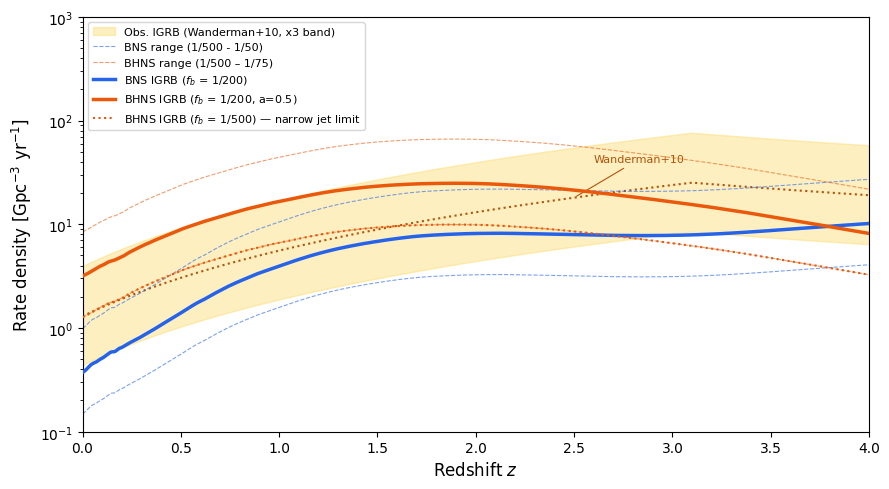

BNS  lGRB z=0 (fb=1/200):  0.37 Gpc^-3 yr^-1
BHNS lGRB z=0 (fb=1/200):  3.16 Gpc^-3 yr^-1
BHNS lGRB z=0 (fb=1/500):  1.26 Gpc^-3 yr^-1
Observed mid   z=0:         1.30 Gpc^-3 yr^-1
Observed range z=0:         0.43 - 3.90 Gpc^-3 yr^-1


In [198]:
# ── Beaming correction ────────────────────────────────────────────────────
# fb = 1 - cos(theta_jet).  Fiducial: theta_jet ~ 5.7 deg -> fb = 1/200.
# Range: fb_lo = 1/500, fb_hi = 1/50  (Fong+15, Berger 2014).
fb_fid = 1.0 / 200.0
fb_lo  = 1.0 / 500.0
fb_hi  = 1.0 / 75.0   # theta_jet ~ 11 deg, conservative upper limit

r_bns_long  = merger_rates_BNS['Long cbGRB']
r_bhns_long = merger_rates_BHNS['Long cbGRB (a=0.5)']

bns_fid   = r_bns_long  * fb_fid
bhns_fid  = r_bhns_long * fb_fid
bhns_cons = r_bhns_long * fb_lo    # conservative fb=1/500 line

bns_lo,  bns_hi  = r_bns_long  * fb_lo, r_bns_long  * fb_hi
bhns_lo, bhns_hi = r_bhns_long * fb_lo, r_bhns_long * fb_hi

# ── Observational lGRB rate density (Wanderman & Piran 2010) ─────────────
# Broken power-law: rho ~ (1+z)^2.1 for z<3.1, (1+z)^-1.4 for z>3.1
# Local rate rho_0 = 1.3 Gpc^-3 yr^-1; uncertainty factor x3.
# The x3 band is observational (folds in luminosity function systematics),
# not a statistical confidence interval -- see Wanderman & Piran 2010 Sec 4.2.
rho0   = 1.3
z_br   = 3.1
obs_mid = np.where(redshifts < z_br,
                   rho0 * (1 + redshifts)**2.1,
                   rho0 * (1 + z_br)**2.1 * ((1 + redshifts)/(1 + z_br))**(-1.4))
obs_lo  = obs_mid / 3.0
obs_hi  = obs_mid * 3.0

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

# Observational band
ax.fill_between(redshifts, obs_lo, obs_hi, color='#FCD34D', alpha=0.35, zorder=1,
                label='Obs. lGRB (Wanderman+10, x3 band)')
ax.plot(redshifts, obs_mid, color='#B45309', lw=1.5, ls=':', zorder=2)
# Direct label on the curve at z~1.5
iz = np.argmin(np.abs(redshifts - 2.5))
ax.annotate('Wanderman+10', xy=(redshifts[iz], obs_mid[iz]),
            xytext=(2.6, obs_mid[iz]*2.2), fontsize=8, color='#B45309',
            arrowprops=dict(arrowstyle='-', color='#B45309', lw=0.8))

# BNS beaming range: two thin dashed boundary lines, no fill
ax.plot(redshifts, bns_lo, color='#2563EB', lw=0.8, ls='--', alpha=0.6)
ax.plot(redshifts, bns_hi, color='#2563EB', lw=0.8, ls='--', alpha=0.6,
        label='BNS range (1/500 - 1/50)')

# BHNS beaming range: two thin dashed boundary lines, no fill
ax.plot(redshifts, bhns_lo, color='#EA580C', lw=0.8, ls='--', alpha=0.6)
ax.plot(redshifts, bhns_hi, color='#EA580C', lw=0.8, ls='--', alpha=0.6,
        label='BHNS range (1/500 – 1/75)')

# Fiducial lines
ax.plot(redshifts, bns_fid,  color='#2563EB', lw=2.5, ls='-',  zorder=3,
        label=r'BNS lGRB ($f_b$ = 1/200)')
ax.plot(redshifts, bhns_fid, color='#EA580C', lw=2.5, ls='-',  zorder=3,
        label=r'BHNS lGRB ($f_b$ = 1/200, a=0.5)')

# Conservative BHNS line: fb=1/500 — if this enters the obs band, it constrains spin
ax.plot(redshifts, bhns_cons, color='#EA580C', lw=1.5, ls=':',  zorder=3,
        label=r'BHNS lGRB ($f_b$ = 1/500) — narrow jet limit')

ax.set_xlim(0, 4)
ax.set_ylim(1e-1, 1e3)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_bns_bhns_dominance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"BNS  lGRB z=0 (fb=1/200):  {bns_fid[0]:.2f} Gpc^-3 yr^-1")
print(f"BHNS lGRB z=0 (fb=1/200):  {bhns_fid[0]:.2f} Gpc^-3 yr^-1")
print(f"BHNS lGRB z=0 (fb=1/500):  {bhns_cons[0]:.2f} Gpc^-3 yr^-1")
print(f"Observed mid   z=0:         {obs_mid[0]:.2f} Gpc^-3 yr^-1")
print(f"Observed range z=0:         {obs_lo[0]:.2f} - {obs_hi[0]:.2f} Gpc^-3 yr^-1")


## 12. BNS vs BHNS Dominance of Long cbGRB Channel

Which progenitor channel dominates long cbGRBs — and does it change with redshift?
BNS and BHNS long cbGRB rates sum to 100% at each z.
At low z, the higher BHNS formation efficiency (boosted by massive BH+NS systems) dominates.
At high z, low-metallicity environments preferentially increase BNS long cbGRB production,
driving a channel crossover.

Channel crossover at z = 3.79
z=0:  BNS 10.5%   BHNS 89.5%
z=1:  BNS 19.2%   BHNS 80.8%
z=3:  BNS 32.3%   BHNS 67.7%


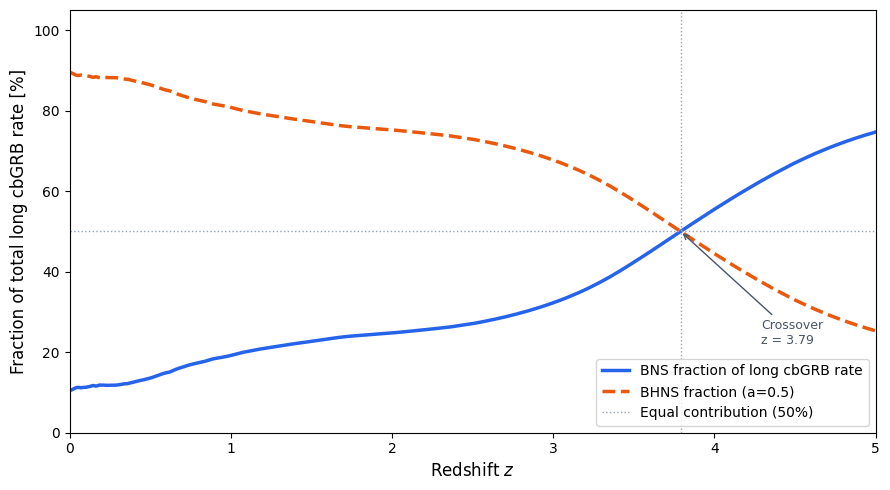

In [199]:
r_bns_long  = merger_rates_BNS['Long cbGRB']
r_bhns_long = merger_rates_BHNS['Long cbGRB (a=0.5)']

total_long = r_bns_long + r_bhns_long
safe_total = np.where(total_long > 0, total_long, np.nan)

frac_bns  = r_bns_long  / safe_total * 100
frac_bhns = r_bhns_long / safe_total * 100

# Find crossover redshift where BNS fraction crosses 50%
cross_idx = np.where(np.diff(np.sign(frac_bns - 50)))[0]
z_cross = redshifts[cross_idx[0]] if len(cross_idx) > 0 else None

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(redshifts, frac_bns,  color='#2563EB', lw=2.5, label='BNS fraction of long cbGRB rate')
ax.plot(redshifts, frac_bhns, color='#EA580C', lw=2.5, ls='--', label='BHNS fraction (a=0.5)')
ax.axhline(50, color='#94A3B8', lw=1, ls=':', label='Equal contribution (50%)')

# Annotate the crossover
if z_cross is not None:
    ax.axvline(z_cross, color='#94A3B8', lw=1, ls=':')
    ax.annotate(f'Crossover\nz = {z_cross:.2f}',
                xy=(z_cross, 50),
                xytext=(z_cross + 0.5, 22),
                fontsize=9, color='#475569',
                arrowprops=dict(arrowstyle='->', color='#475569', lw=1.0))
    print(f"Channel crossover at z = {z_cross:.2f}")

print(f"z=0:  BNS {frac_bns[0]:.1f}%   BHNS {frac_bhns[0]:.1f}%")
iz1 = np.argmin(np.abs(redshifts - 1.0))
print(f"z=1:  BNS {frac_bns[iz1]:.1f}%   BHNS {frac_bhns[iz1]:.1f}%")
iz3 = np.argmin(np.abs(redshifts - 3.0))
print(f"z=3:  BNS {frac_bns[iz3]:.1f}%   BHNS {frac_bhns[iz3]:.1f}%")

ax.set_xlim(0, 5)
ax.set_ylim(0, 105)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Fraction of total long cbGRB rate [%]', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/Plots/rate_long_grb_channel_fraction.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Export

In [200]:
np.save('/Users/josephrodriguez/research visualization/results/rates_BNS.npy',
        np.array([redshifts,
                  merger_rates_BNS['All BNS'],
                  merger_rates_BNS['Short cbGRB'],
                  merger_rates_BNS['Long cbGRB']]))

np.save('/Users/josephrodriguez/research visualization/results/rates_BHNS.npy',
        np.array([redshifts,
                  merger_rates_BHNS['All BHNS'],
                  merger_rates_BHNS['Long cbGRB (a=0.5)']]))

print("Rates saved to rates_BNS.npy and rates_BHNS.npy")

Rates saved to rates_BNS.npy and rates_BHNS.npy
